<a href="https://colab.research.google.com/github/saranya-45/machine-learning/blob/main/Plant_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/PlantVillage'

In [ ]:
import os
print(os.listdir(dataset_path))

['Tomato_Early_blight', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato__Tomato_mosaic_virus', 'Tomato_Septoria_leaf_spot', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Potato___Late_blight', 'Potato___healthy', 'Potato___Early_blight', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 16546 images belonging to 15 classes.
Found 4130 images belonging to 15 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(15, activation='softmax')
])

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
epochs = 10

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    steps_per_epoch=1000 // 32,        # use ~1000 training images
    validation_steps=200 // 32         # use ~200 validation images
)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 244s 8s/step - accuracy: 0.4244 - loss: 1.9021 - val_accuracy: 0.6667 - val_loss: 1.3371
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 216s 7s/step - accuracy: 0.5202 - loss: 1.5271 - val_accuracy: 0.6562 - val_loss: 1.1331
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 201s 7s/step - accuracy: 0.6240 - loss: 1.1566 - val_accuracy: 0.7135 - val_loss: 0.9052
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 156s 5s/step - accuracy: 0.6431 - loss: 1.1692 - val_accuracy: 0.7604 - val_loss: 0.8439
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 144s 5s/step - accuracy: 0.6734 - loss: 1.0303 - val_accuracy: 0.7604 - val_loss: 0.6625
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 143s 5s/step - accuracy: 0.7097 - loss: 0.9306 - val_accuracy: 0.8333 - val_loss: 0.6132
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 116s 4s/step - accuracy: 0.7208 - loss: 0.9062 - val_accuracy: 0.8073 - val_loss: 0.6322
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 123s 4s/step - accuracy: 0.7137 - loss: 0.8882 - val_accuracy: 0.7552 - v

In [ ]:
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

Training Accuracy: 0.7419354915618896
Validation Accuracy: 0.8854166865348816


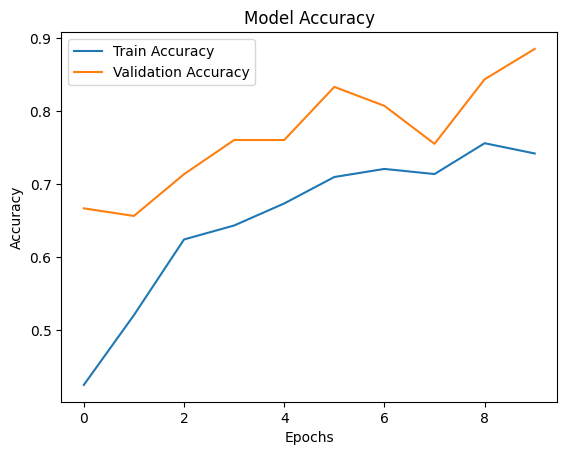

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Train Accuracy', 'Validation Accuracy'])

plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [ ]:
y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data.classes

130/130 ━━━━━━━━━━━━━━━━━━━━ 407s 3s/step


In [ ]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.04      0.04      0.04       199
           1       0.05      0.06      0.06       295
           2       0.03      0.03      0.03       200
           3       0.06      0.06      0.06       200
           4       0.00      0.00      0.00        30
           5       0.09      0.12      0.10       425
           6       0.08      0.04      0.06       200
           7       0.09      0.09      0.09       381
           8       0.06      0.07      0.06       190
           9       0.09      0.07      0.08       354
          10       0.08      0.10      0.09       335
          11       0.06      0.05      0.06       280
          12       0.14      0.14      0.14       647
          13       0.00      0.00      0.00        74
          14       0.07      0.07      0.07       320

    accuracy                           0.08      4130
   macro avg       0.06      0.06      0.06      4130
weighted avg       0.08   

In [ ]:
print(confusion_matrix(y_true, y_pred_classes))

[[ 7 17  8 15  0 28  4 17 15 11 21 15 28  1 12]
 [12 18 22 10  1 39  9 32 25 15 25 13 48  5 21]
 [ 7 14  6 10  0 23  7 24 12 19 15  7 35  1 20]
 [ 7 15 11 11  0 27  3 24 13 13 17 12 31  1 15]
 [ 2  4  3  1  0  4  1  4  1  0  4  2  3  0  1]
 [21 34 27 27  0 49 11 54 19 35 32 22 66  1 27]
 [ 6 19 15 11  0 25  9 15  7 13 23 13 28  1 15]
 [11 27  9 16  1 60 13 36 19 30 42 14 63  5 35]
 [ 9 16 13 12  0 28  5 15 13 11 18 10 29  0 11]
 [10 35 17 14  1 45 10 34 20 25 30 24 62  1 26]
 [ 9 34 16 10  3 41  6 26 13 24 32 28 65  5 23]
 [ 9 27 15 10  0 45  6 23 13 13 28 15 45  1 30]
 [31 55 33 34  2 78 18 66 34 43 69 40 93  4 47]
 [ 4  3  5  4  0 10  1 10  4  4  8  4  9  0  8]
 [14 22 11 15  0 51 11 33 22 19 35 20 42  3 22]]
